---

---

## Import Libraries 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV,
    learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB


from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    VotingRegressor, VotingClassifier,
    StackingRegressor, StackingClassifier
)
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import json
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully')

All libraries imported successfully


## Load Dataset

In [2]:
df = pd.read_csv('Fifa.csv')
print('Dataset Shape:', df.shape)
df.head(10)

Dataset Shape: (19667, 9)


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640
5,Abdel Rahman Boudi,Egypt,RB,27,65,67,Ittihad Alexandria,0.45,1610
6,Karim El Deeb,Egypt,CM,33,67,67,Ittihad Alexandria,0.30,1680
7,Mohamed Tony,Egypt,CDM,29,66,67,Ittihad Alexandria,0.38,1655
8,Nour Alaa El Din,Egypt,CAM,24,64,70,Ittihad Alexandria,0.60,1590
9,Fady Farid,Egypt,ST,28,67,68,Ittihad Alexandria,0.55,1670


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [4]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


## EDA: Missing Values 

In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print()
if missing.sum() == 0:
    print('No missing values found in the dataset.')
else:
    print(f'Total missing values: {missing.sum()}')

                   Missing Count  Missing %
Name                           0        0.0
Country                        0        0.0
Position                       0        0.0
Age                            0        0.0
Overall_Rating                 0        0.0
Future Potential               0        0.0
Team                           0        0.0
Value Per M$                   0        0.0
Total_Stats Score              0        0.0

No missing values found in the dataset.


## EDA: Target Distribution 

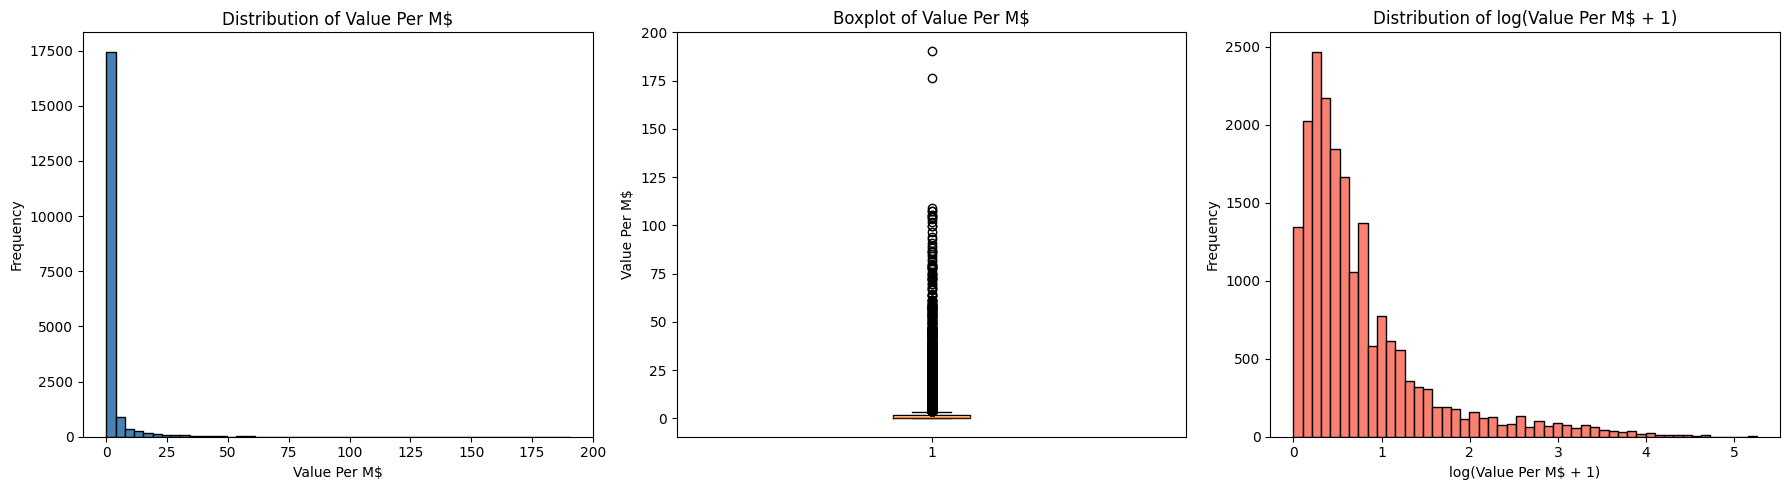

Skewness of Value Per M$: 7.9832
The distribution is highly skewed (|skewness| > 1). A log transformation is recommended.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['Value Per M$'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Value Per M$')
axes[0].set_xlabel('Value Per M$')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['Value Per M$'], vert=True)
axes[1].set_title('Boxplot of Value Per M$')
axes[1].set_ylabel('Value Per M$')

axes[2].hist(np.log1p(df['Value Per M$']), bins=50, color='salmon', edgecolor='black')
axes[2].set_title('Distribution of log(Value Per M$ + 1)')
axes[2].set_xlabel('log(Value Per M$ + 1)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

skewness = df['Value Per M$'].skew()
print(f'Skewness of Value Per M$: {skewness:.4f}')
if abs(skewness) > 1:
    print('The distribution is highly skewed (|skewness| > 1). A log transformation is recommended.')

## EDA: Correlation Heatmap 

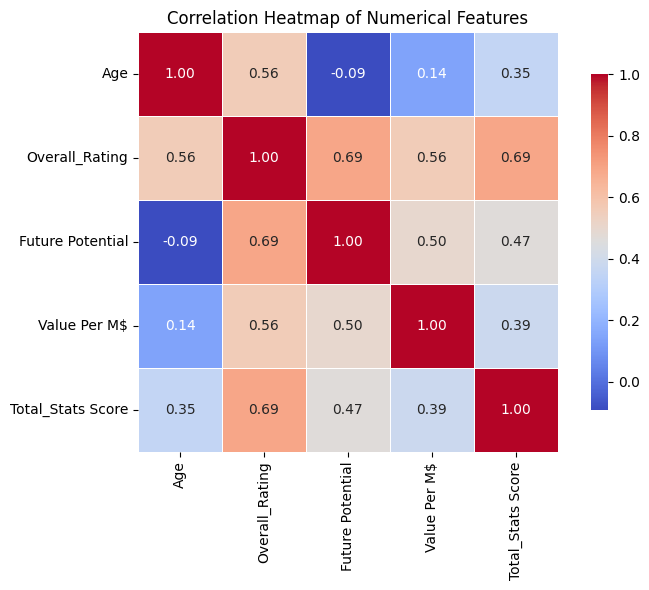

Correlation with Value Per M$:
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


In [7]:
numerical_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

print('Correlation with Value Per M$:')
print(corr_matrix['Value Per M$'].sort_values(ascending=False))

## EDA: Scatter Plots & Position Bar Chart 

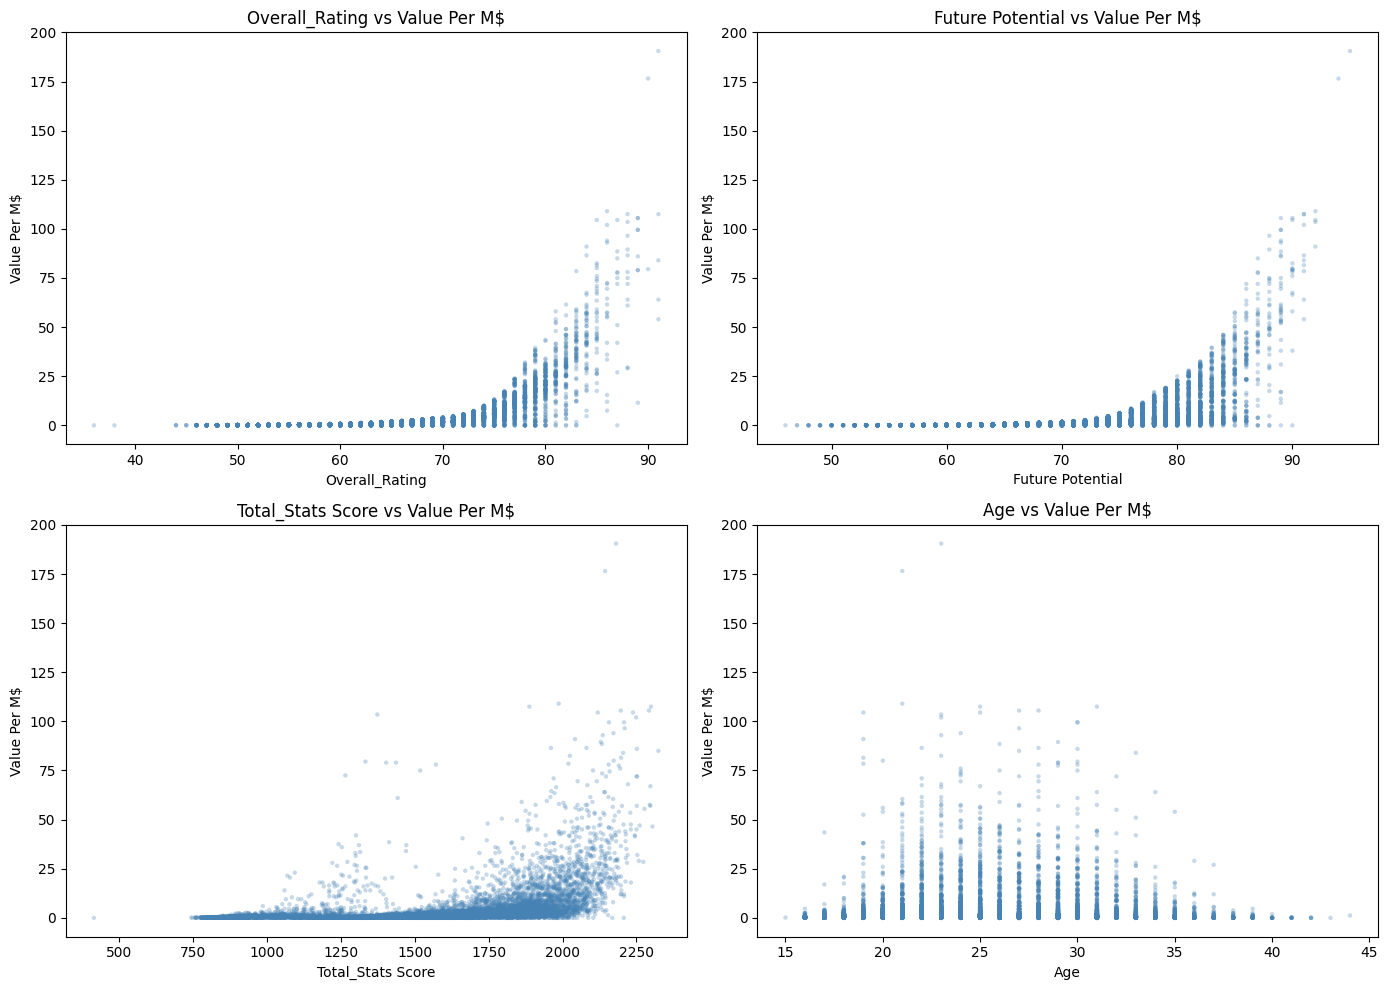

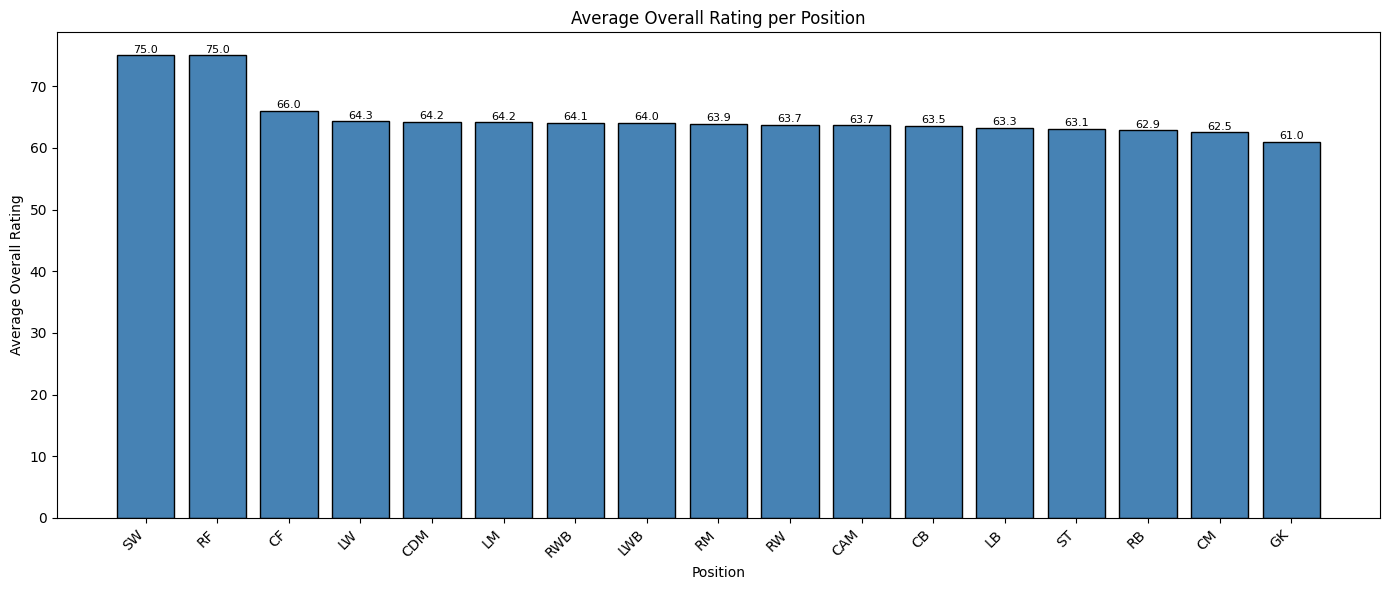

In [8]:
features_to_plot = ['Overall_Rating', 'Future Potential', 'Total_Stats Score', 'Age']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    axes[i].scatter(df[feat], df['Value Per M$'], alpha=0.3, color='steelblue', edgecolors='none', s=10)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Value Per M$')
    axes[i].set_title(f'{feat} vs Value Per M$')
plt.tight_layout()
plt.show()

avg_rating = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(14, 6))
bars = plt.bar(avg_rating.index, avg_rating.values, color='steelblue', edgecolor='black')
plt.title('Average Overall Rating per Position')
plt.xlabel('Position')
plt.ylabel('Average Overall Rating')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## Data Preprocessing: Split FIRST 

In [9]:
# Split BEFORE any preprocessing to prevent data leakage
X = df.drop(columns=['Name', 'Value Per M$'])
y_reg = df['Value Per M$']

X_train_raw, X_test_raw, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.20, random_state=42)

print(f'Train size: {X_train_raw.shape[0]}  |  Test size: {X_test_raw.shape[0]}')

Train size: 15733  |  Test size: 3934


## One-Hot Encoding 

In [10]:
categorical_cols = ['Country', 'Position', 'Team']
numerical_cols   = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

# Fit OHE only on training data
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train_raw[categorical_cols])

train_ohe = ohe.transform(X_train_raw[categorical_cols])
test_ohe  = ohe.transform(X_test_raw[categorical_cols])

ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_feature_names, index=X_train_raw.index)
test_ohe_df  = pd.DataFrame(test_ohe,  columns=ohe_feature_names, index=X_test_raw.index)

print(f'Number of OHE features: {train_ohe_df.shape[1]}')

Number of OHE features: 1176


## Feature Scaling 

In [11]:
# Fit scaler only on training data
scaler = StandardScaler()
scaler.fit(X_train_raw[numerical_cols])

train_num_scaled = scaler.transform(X_train_raw[numerical_cols])
test_num_scaled  = scaler.transform(X_test_raw[numerical_cols])

train_num_df = pd.DataFrame(train_num_scaled, columns=numerical_cols, index=X_train_raw.index)
test_num_df  = pd.DataFrame(test_num_scaled,  columns=numerical_cols, index=X_test_raw.index)

print('Numerical features scaled.')

Numerical features scaled.


## Outlier Capping on Target 

In [12]:
Q1 = y_train_reg.quantile(0.25)
Q3 = y_train_reg.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (y_train_reg >= lower_bound) & (y_train_reg <= upper_bound)
print(f'IQR Bounds — Lower: {lower_bound:.3f}  Upper: {upper_bound:.3f}')
print(f'Outliers detected in target (train): {(~outlier_mask).sum()}')

y_train_reg_capped = y_train_reg.clip(lower_bound, upper_bound)
print(f'Outliers capped. New max in train target: {y_train_reg_capped.max():.3f}')

IQR Bounds — Lower: -1.588  Upper: 3.513
Outliers detected in target (train): 1897
Outliers capped. New max in train target: 3.513


## Assemble Feature Sets 

In [13]:
# Full feature set: numerical + OHE
X_train_full = pd.concat([train_num_df, train_ohe_df], axis=1)
X_test_full  = pd.concat([test_num_df,  test_ohe_df],  axis=1)

# Numerical-only set
X_train_num = train_num_df.copy()
X_test_num  = test_num_df.copy()

print(f'Full feature set  — Train: {X_train_full.shape}  Test: {X_test_full.shape}')
print(f'Numerical only    — Train: {X_train_num.shape}  Test: {X_test_num.shape}')

Full feature set  — Train: (15733, 1180)  Test: (3934, 1180)
Numerical only    — Train: (15733, 4)  Test: (3934, 4)


## Classification Target: Performance Tiers 

25th percentile: 58.0
50th percentile: 63.0
75th percentile: 68.0


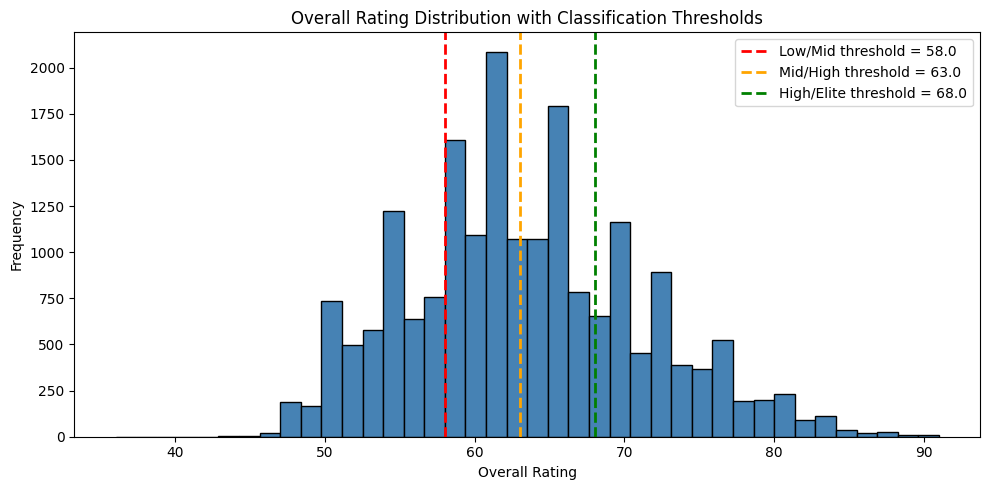

In [14]:
p25 = df['Overall_Rating'].quantile(0.25)
p50 = df['Overall_Rating'].quantile(0.50)
p75 = df['Overall_Rating'].quantile(0.75)

print(f'25th percentile: {p25}')
print(f'50th percentile: {p50}')
print(f'75th percentile: {p75}')

plt.figure(figsize=(10, 5))
plt.hist(df['Overall_Rating'], bins=40, color='steelblue', edgecolor='black')
for p, label, color in [(p25,'Low/Mid','red'), (p50,'Mid/High','orange'), (p75,'High/Elite','green')]:
    plt.axvline(p, color=color, linestyle='--', linewidth=2, label=f'{label} threshold = {p}')
plt.title('Overall Rating Distribution with Classification Thresholds')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

Label mapping: {np.str_('Elite'): np.int64(0), np.str_('High'): np.int64(1), np.str_('Low'): np.int64(2), np.str_('Mid'): np.int64(3)}

Class distribution (full dataset):
Tier
Elite    5352
Low      4807
Mid      4791
High     4717
Name: count, dtype: int64


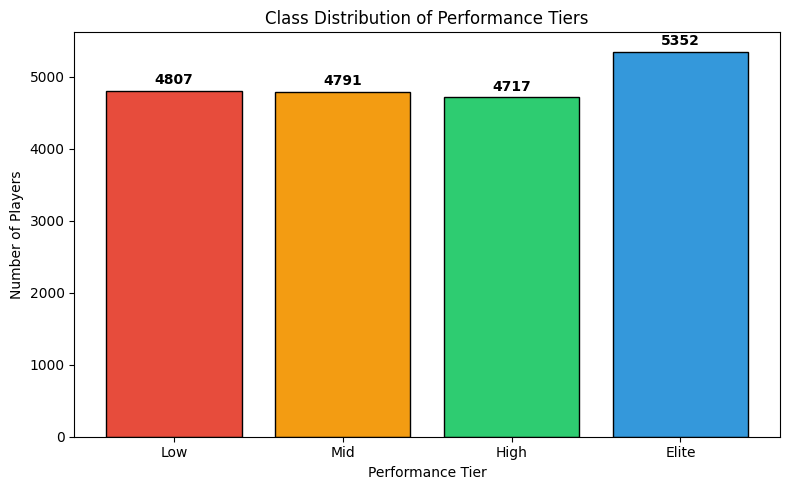

In [15]:
def assign_tier(rating):
    if rating < 58:   return 'Low'
    elif rating < 63: return 'Mid'
    elif rating < 68: return 'High'
    else:             return 'Elite'

df['Tier'] = df['Overall_Rating'].apply(assign_tier)

le = LabelEncoder()
le.fit(['Low', 'Mid', 'High', 'Elite'])
df['Tier_encoded'] = le.transform(df['Tier'])

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print()
print('Class distribution (full dataset):')
print(df['Tier'].value_counts())

# Assign tiers to train/test splits
y_train_cls = le.transform(
    X_train_raw.index.map(lambda i: assign_tier(df.loc[i, 'Overall_Rating'])).tolist()
)
y_test_cls = le.transform(
    X_test_raw.index.map(lambda i: assign_tier(df.loc[i, 'Overall_Rating'])).tolist()
)

# Class distribution bar chart
tier_counts = df['Tier'].value_counts().reindex(['Low', 'Mid', 'High', 'Elite'])
plt.figure(figsize=(8, 5))
bars = plt.bar(['Low', 'Mid', 'High', 'Elite'], tier_counts.values,
               color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'], edgecolor='black')
plt.title('Class Distribution of Performance Tiers')
plt.xlabel('Performance Tier')
plt.ylabel('Number of Players')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(bar.get_height()), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## Polynomial Ridge Regression

In [16]:
reg_num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

scaler_reg = StandardScaler()
scaler_reg.fit(X_train_raw[reg_num_cols])
X_train_reg_num = scaler_reg.transform(X_train_raw[reg_num_cols])
X_test_reg_num  = scaler_reg.transform(X_test_raw[reg_num_cols])

def eval_regression(y_true_train, y_pred_train, y_true_test, y_pred_test, model_name='Model'):
    print(f"{'='*50}")
    print(f'  {model_name}')
    print(f"{'='*50}")
    print(f"  {'Metric':<10} {'Train':>12} {'Test':>12}")
    print(f"  {'-'*36}")
    for metric, fn in [('MAE', mean_absolute_error),
                       ('MSE', mean_squared_error),
                       ('RMSE', lambda a,b: np.sqrt(mean_squared_error(a,b))),
                       ('R²',  r2_score)]:
        tr = fn(y_true_train, y_pred_train)
        te = fn(y_true_test,  y_pred_test)
        print(f'  {metric:<10} {tr:>12.4f} {te:>12.4f}')
    print()

# Sweep polynomial degrees
degrees = [1, 2, 3, 4]
test_r2_scores = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Xtr = poly.fit_transform(X_train_reg_num)
    Xte = poly.transform(X_test_reg_num)
    m = LinearRegression().fit(Xtr, y_train_reg_capped)
    test_r2_scores.append(r2_score(y_test_reg, m.predict(Xte)))
    print(f'Degree {degree}: Test R² = {test_r2_scores[-1]:.4f}')

best_degree = degrees[np.argmax(test_r2_scores)]
print(f'\nBest polynomial degree: {best_degree}')

poly_best = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly = poly_best.fit_transform(X_train_reg_num)
X_test_poly  = poly_best.transform(X_test_reg_num)

# Ridge at best alpha
alphas = np.logspace(-3, 4, 50)
ridge_test_rmse = []
for alpha in alphas:
    r = Ridge(alpha=alpha).fit(X_train_poly, y_train_reg_capped)
    ridge_test_rmse.append(np.sqrt(mean_squared_error(y_test_reg, r.predict(X_test_poly))))
best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]

ridge_a2 = Ridge(alpha=best_ridge_alpha).fit(X_train_poly, y_train_reg_capped)
y_pred_ridge_a2 = ridge_a2.predict(X_test_poly)

eval_regression(y_train_reg_capped, ridge_a2.predict(X_train_poly),
                y_test_reg, y_pred_ridge_a2, f'Assignment 2 — Ridge (alpha={best_ridge_alpha:.4f})')

# Store baseline metrics for comparison
a2_reg_r2   = r2_score(y_test_reg, y_pred_ridge_a2)
a2_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge_a2))

Degree 1: Test R² = 0.1002
Degree 2: Test R² = 0.1364
Degree 3: Test R² = 0.1007
Degree 4: Test R² = 0.0878

Best polynomial degree: 2
  Assignment 2 — Ridge (alpha=0.0010)
  Metric            Train         Test
  ------------------------------------
  MAE              0.2817       1.6797
  MSE              0.1975      53.5680
  RMSE             0.4445       7.3190
  R²               0.8438       0.1364



## Logistic Regression Classifier

Assignment 2 — Logistic Regression (best C=0.1600)
              precision    recall  f1-score   support

       Elite       0.91      0.87      0.89      1085
        High       0.70      0.73      0.71       914
         Low       0.90      0.88      0.89      1014
         Mid       0.71      0.73      0.72       921

    accuracy                           0.81      3934
   macro avg       0.81      0.80      0.80      3934
weighted avg       0.81      0.81      0.81      3934



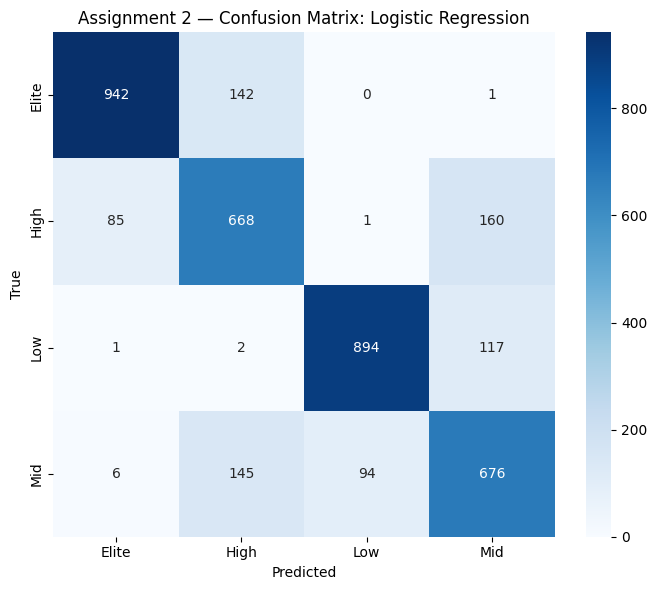

Assignment 2 Baseline — Accuracy: 0.8083  Weighted F1: 0.8100


In [17]:
cls_num_cols = ['Age', 'Future Potential', 'Total_Stats Score']
scaler_cls = StandardScaler()
scaler_cls.fit(X_train_raw[cls_num_cols])
X_train_cls_num = scaler_cls.transform(X_train_raw[cls_num_cols])
X_test_cls_num  = scaler_cls.transform(X_test_raw[cls_num_cols])

X_train_cls_num_df = pd.DataFrame(X_train_cls_num, columns=cls_num_cols, index=X_train_raw.index)
X_test_cls_num_df  = pd.DataFrame(X_test_cls_num,  columns=cls_num_cols, index=X_test_raw.index)

X_train_cls_full = pd.concat([X_train_cls_num_df, train_ohe_df], axis=1)
X_test_cls_full  = pd.concat([X_test_cls_num_df,  test_ohe_df],  axis=1)

# Sweep C
C_values = np.logspace(-3, 3, 50)
lr_test_acc = []
for C in C_values:
    m = LogisticRegression(C=C, max_iter=1000, random_state=42).fit(X_train_cls_full, y_train_cls)
    lr_test_acc.append(accuracy_score(y_test_cls, m.predict(X_test_cls_full)))
best_C = C_values[np.argmax(lr_test_acc)]

log_reg_a2 = LogisticRegression(C=best_C, max_iter=1000, random_state=42)
log_reg_a2.fit(X_train_cls_full, y_train_cls)
y_pred_lr_a2 = log_reg_a2.predict(X_test_cls_full)

print('Assignment 2 — Logistic Regression (best C={:.4f})'.format(best_C))
print('='*60)
print(classification_report(y_test_cls, y_pred_lr_a2, target_names=le.classes_))

cm = confusion_matrix(y_test_cls, y_pred_lr_a2)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Assignment 2 — Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Store baseline metric
a2_cls_acc = accuracy_score(y_test_cls, y_pred_lr_a2)
a2_cls_f1  = f1_score(y_test_cls, y_pred_lr_a2, average='weighted')
print(f'Assignment 2 Baseline — Accuracy: {a2_cls_acc:.4f}  Weighted F1: {a2_cls_f1:.4f}')

## Naïve Bayes (GaussianNB, BernoulliNB, ComplementNB)

In [18]:
gnb = GaussianNB().fit(X_train_cls_num, y_train_cls)
bnb = BernoulliNB().fit(train_ohe_df, y_train_cls)
cnb = ComplementNB().fit(train_ohe_df, y_train_cls)

for name, model, Xtr, Xte in [
    ('GaussianNB',   gnb, X_train_cls_num, X_test_cls_num),
    ('BernoulliNB',  bnb, train_ohe_df,    test_ohe_df),
    ('ComplementNB', cnb, train_ohe_df,    test_ohe_df)
]:
    preds = model.predict(Xte)
    acc = accuracy_score(y_test_cls, preds)
    f1  = f1_score(y_test_cls, preds, average='weighted')
    print(f'{name:<15} — Accuracy: {acc:.4f}  F1: {f1:.4f}')

print()
print('GaussianNB is best for continuous numerical features (Age, Future Potential, Total Stats).')
print('BernoulliNB / ComplementNB are appropriate for the binary OHE feature columns.')

GaussianNB      — Accuracy: 0.6950  F1: 0.7007
BernoulliNB     — Accuracy: 0.5092  F1: 0.4969
ComplementNB    — Accuracy: 0.5000  F1: 0.4862

GaussianNB is best for continuous numerical features (Age, Future Potential, Total Stats).
BernoulliNB / ComplementNB are appropriate for the binary OHE feature columns.


## KFold + StratifiedKFold Cross-Validation

In [19]:
# KFold CV — Ridge Regression
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_rmse = []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_poly)):
    Xf_tr, Xf_val = X_train_poly[tr_idx], X_train_poly[val_idx]
    yf_tr  = np.array(y_train_reg_capped)[tr_idx]
    yf_val = np.array(y_train_reg_capped)[val_idx]
    r = Ridge(alpha=best_ridge_alpha).fit(Xf_tr, yf_tr)
    rmse = np.sqrt(mean_squared_error(yf_val, r.predict(Xf_val)))
    fold_rmse.append(rmse)
    print(f'  Fold {fold+1}: RMSE = {rmse:.4f}')
print(f'\nRidge CV — Mean RMSE: {np.mean(fold_rmse):.4f}  Std: {np.std(fold_rmse):.4f}')

# StratifiedKFold CV — Logistic Regression
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_cls_arr = X_train_cls_full.values
lr_fold_acc = []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cls_arr, y_train_cls)):
    m = LogisticRegression(C=best_C, max_iter=1000, random_state=42)
    m.fit(X_cls_arr[tr_idx], y_train_cls[tr_idx])
    acc = accuracy_score(y_train_cls[val_idx], m.predict(X_cls_arr[val_idx]))
    lr_fold_acc.append(acc)
    print(f'  Fold {fold+1}: Accuracy = {acc:.4f}')
print(f'\nLogReg CV — Mean Acc: {np.mean(lr_fold_acc):.4f}  Std: {np.std(lr_fold_acc):.4f}')

  Fold 1: RMSE = 0.4555
  Fold 2: RMSE = 0.4506
  Fold 3: RMSE = 0.4347
  Fold 4: RMSE = 0.4374
  Fold 5: RMSE = 0.4484

Ridge CV — Mean RMSE: 0.4453  Std: 0.0079
  Fold 1: Accuracy = 0.7998
  Fold 2: Accuracy = 0.8036
  Fold 3: Accuracy = 0.8093
  Fold 4: Accuracy = 0.8058
  Fold 5: Accuracy = 0.8074

LogReg CV — Mean Acc: 0.8052  Std: 0.0033


---
## UNIFIED SCOUTING SYSTEM
---

## Model Selection Justification

Three diverse architectures are selected to cover different learning paradigms:

| Model | Family | Justification for FIFA Dataset |
|---|---|---|
| **Random Forest** | Tree-based (ensemble) | Handles non-linear relationships between Overall_Rating and Value (confirmed by scatter plots in EDA). Robust to outliers in the target. Provides feature importance. |
| **SVR / SVC** | Kernel-based | Effective in high-dimensional OHE feature spaces. The RBF kernel can model the curved relationship between player attributes and market value seen in the EDA scatter plots. |
| **KNN** | Instance-based | No training assumptions — classifies/regresses based on similarity. Useful as a contrast: player tiers may cluster naturally in feature space. |

These three cover instance-based, kernel-based, and tree-based families as required by the assignment.

## Unified Preprocessing Pipeline (sklearn Pipeline)

A single ColumnTransformer + Pipeline ensures identical preprocessing for both regression and classification tasks, eliminating inconsistency.

In [ ]:

cat_cols = ['Country', 'Position', 'Team']

#  REGRESSION preprocessor (includes Overall_Rating) 
reg_num_features = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

reg_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), reg_num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

#  CLASSIFICATION preprocessor (excludes Overall_Rating to avoid leakage) 
cls_num_features = ['Age', 'Future Potential', 'Total_Stats Score']

cls_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), cls_num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Raw feature DataFrames (unscaled, with all columns)
X_train_for_pipe = X_train_raw.copy()
X_test_for_pipe  = X_test_raw.copy()

# Fit and transform using the pipeline preprocessors
X_train_reg_pipe = reg_preprocessor.fit_transform(X_train_for_pipe)
X_test_reg_pipe  = reg_preprocessor.transform(X_test_for_pipe)

X_train_cls_pipe = cls_preprocessor.fit_transform(X_train_for_pipe)
X_test_cls_pipe  = cls_preprocessor.transform(X_test_for_pipe)

print(f'Regression pipeline features — Train: {X_train_reg_pipe.shape}  Test: {X_test_reg_pipe.shape}')
print(f'Classification pipeline features — Train: {X_train_cls_pipe.shape}  Test: {X_test_cls_pipe.shape}')
print()
print('Unified preprocessor ensures identical scaling and encoding logic across both tasks.')

Regression pipeline features — Train: (15733, 1180)  Test: (3934, 1180)
Classification pipeline features — Train: (15733, 1179)  Test: (3934, 1179)

Unified preprocessor ensures identical scaling and encoding logic across both tasks.


## Regression: Random Forest + GridSearchCV

In [21]:
# Random Forest Regressor with GridSearch
rf_reg_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_reg = RandomForestRegressor(random_state=42)
gs_rf_reg = GridSearchCV(
    rf_reg, rf_reg_param_grid,
    cv=3, scoring='r2', n_jobs=-1, verbose=0
)
gs_rf_reg.fit(X_train_reg_pipe, y_train_reg_capped)

print('Best RF Regressor params:', gs_rf_reg.best_params_)
print(f'Best CV R²: {gs_rf_reg.best_score_:.4f}')

best_rf_reg = gs_rf_reg.best_estimator_
y_pred_rf_reg = best_rf_reg.predict(X_test_reg_pipe)

eval_regression(y_train_reg_capped, best_rf_reg.predict(X_train_reg_pipe),
                y_test_reg, y_pred_rf_reg, 'Random Forest Regressor (tuned)')

rf_reg_r2   = r2_score(y_test_reg, y_pred_rf_reg)
rf_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))

Best RF Regressor params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.9414
  Random Forest Regressor (tuned)
  Metric            Train         Test
  ------------------------------------
  MAE              0.0474       1.5840
  MSE              0.0089      56.3562
  RMSE             0.0942       7.5071
  R²               0.9930       0.0915



## Regression: SVR + GridSearchCV

In [22]:
svr_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'epsilon': [0.1, 0.5, 1.0]
}

svr = SVR()
gs_svr = GridSearchCV(svr, svr_param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
gs_svr.fit(X_train_reg_pipe, y_train_reg_capped)

print('Best SVR params:', gs_svr.best_params_)
print(f'Best CV R²: {gs_svr.best_score_:.4f}')

best_svr = gs_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test_reg_pipe)

eval_regression(y_train_reg_capped, best_svr.predict(X_train_reg_pipe),
                y_test_reg, y_pred_svr, 'SVR (tuned)')

svr_r2   = r2_score(y_test_reg, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_svr))

Best SVR params: {'C': 100, 'epsilon': 0.1, 'kernel': 'rbf'}
Best CV R²: 0.9564
  SVR (tuned)
  Metric            Train         Test
  ------------------------------------
  MAE              0.0663       1.5667
  MSE              0.0056      56.1504
  RMSE             0.0749       7.4934
  R²               0.9956       0.0948



## Regression: KNN Regressor + GridSearchCV

In [23]:
knn_reg_param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

knn_reg = KNeighborsRegressor()
gs_knn_reg = GridSearchCV(knn_reg, knn_reg_param_grid, cv=3, scoring='r2', n_jobs=-1)
gs_knn_reg.fit(X_train_reg_pipe, y_train_reg_capped)

print('Best KNN Regressor params:', gs_knn_reg.best_params_)
print(f'Best CV R²: {gs_knn_reg.best_score_:.4f}')

best_knn_reg = gs_knn_reg.best_estimator_
y_pred_knn_reg = best_knn_reg.predict(X_test_reg_pipe)

eval_regression(y_train_reg_capped, best_knn_reg.predict(X_train_reg_pipe),
                y_test_reg, y_pred_knn_reg, 'KNN Regressor (tuned)')

knn_reg_r2   = r2_score(y_test_reg, y_pred_knn_reg)
knn_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_knn_reg))

Best KNN Regressor params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Best CV R²: 0.9171
  KNN Regressor (tuned)
  Metric            Train         Test
  ------------------------------------
  MAE              0.0000       1.6314
  MSE              0.0000      56.2469
  RMSE             0.0000       7.4998
  R²               1.0000       0.0933



## Classification: Random Forest + GridSearchCV

Best RF Classifier params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy: 0.8302

Random Forest Classifier (tuned) — Test Set
              precision    recall  f1-score   support

       Elite       0.94      0.92      0.93      1085
        High       0.77      0.76      0.77       914
         Low       0.88      0.88      0.88      1014
         Mid       0.71      0.74      0.73       921

    accuracy                           0.83      3934
   macro avg       0.83      0.83      0.83      3934
weighted avg       0.83      0.83      0.83      3934



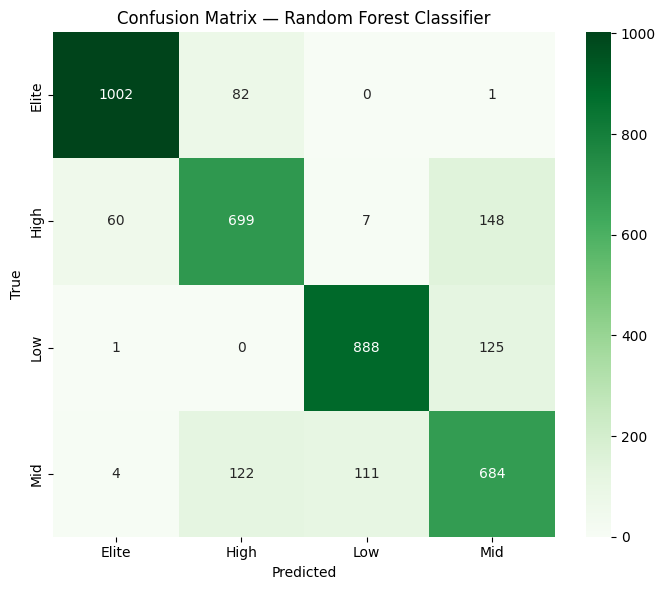

In [24]:
rf_cls_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_cls = RandomForestClassifier(random_state=42)
gs_rf_cls = GridSearchCV(rf_cls, rf_cls_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
gs_rf_cls.fit(X_train_cls_pipe, y_train_cls)

print('Best RF Classifier params:', gs_rf_cls.best_params_)
print(f'Best CV Accuracy: {gs_rf_cls.best_score_:.4f}')

best_rf_cls = gs_rf_cls.best_estimator_
y_pred_rf_cls = best_rf_cls.predict(X_test_cls_pipe)

print('\nRandom Forest Classifier (tuned) — Test Set')
print('='*60)
print(classification_report(y_test_cls, y_pred_rf_cls, target_names=le.classes_))

rf_cls_acc = accuracy_score(y_test_cls, y_pred_rf_cls)
rf_cls_f1  = f1_score(y_test_cls, y_pred_rf_cls, average='weighted')

cm = confusion_matrix(y_test_cls, y_pred_rf_cls)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Classification: SVC + GridSearchCV

Best SVC params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.8519

SVC (tuned) — Test Set
              precision    recall  f1-score   support

       Elite       0.95      0.93      0.94      1085
        High       0.80      0.81      0.80       914
         Low       0.91      0.88      0.90      1014
         Mid       0.75      0.79      0.77       921

    accuracy                           0.86      3934
   macro avg       0.85      0.85      0.85      3934
weighted avg       0.86      0.86      0.86      3934



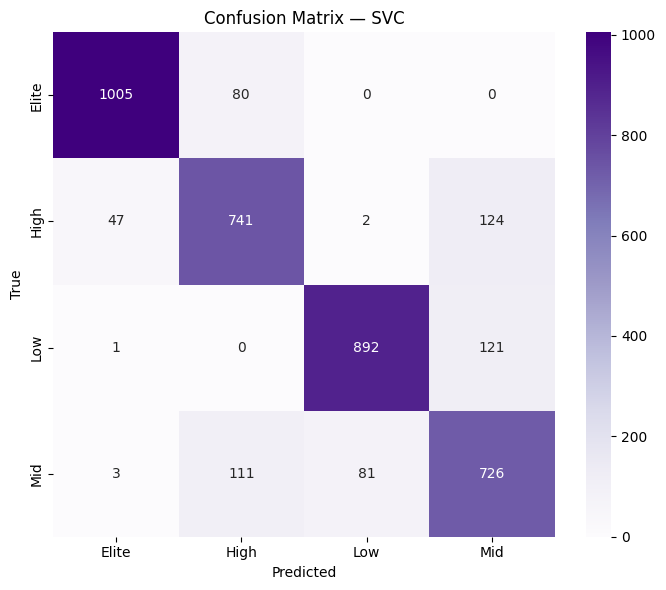

In [25]:
svc_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svc = SVC(random_state=42)
gs_svc = GridSearchCV(svc, svc_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
gs_svc.fit(X_train_cls_pipe, y_train_cls)

print('Best SVC params:', gs_svc.best_params_)
print(f'Best CV Accuracy: {gs_svc.best_score_:.4f}')

best_svc = gs_svc.best_estimator_
y_pred_svc = best_svc.predict(X_test_cls_pipe)

print('\nSVC (tuned) — Test Set')
print('='*60)
print(classification_report(y_test_cls, y_pred_svc, target_names=le.classes_))

svc_acc = accuracy_score(y_test_cls, y_pred_svc)
svc_f1  = f1_score(y_test_cls, y_pred_svc, average='weighted')

cm = confusion_matrix(y_test_cls, y_pred_svc)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — SVC')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Classification: KNN Classifier + GridSearchCV

In [26]:
knn_cls_param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

knn_cls = KNeighborsClassifier()
gs_knn_cls = GridSearchCV(knn_cls, knn_cls_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
gs_knn_cls.fit(X_train_cls_pipe, y_train_cls)

print('Best KNN Classifier params:', gs_knn_cls.best_params_)
print(f'Best CV Accuracy: {gs_knn_cls.best_score_:.4f}')

best_knn_cls = gs_knn_cls.best_estimator_
y_pred_knn_cls = best_knn_cls.predict(X_test_cls_pipe)

print('\nKNN Classifier (tuned) — Test Set')
print('='*60)
print(classification_report(y_test_cls, y_pred_knn_cls, target_names=le.classes_))

knn_cls_acc = accuracy_score(y_test_cls, y_pred_knn_cls)
knn_cls_f1  = f1_score(y_test_cls, y_pred_knn_cls, average='weighted')

Best KNN Classifier params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Best CV Accuracy: 0.7642

KNN Classifier (tuned) — Test Set
              precision    recall  f1-score   support

       Elite       0.94      0.85      0.89      1085
        High       0.65      0.68      0.66       914
         Low       0.84      0.84      0.84      1014
         Mid       0.60      0.64      0.62       921

    accuracy                           0.76      3934
   macro avg       0.76      0.75      0.75      3934
weighted avg       0.77      0.76      0.76      3934



## Bias-Variance Diagnosis via Learning Curves

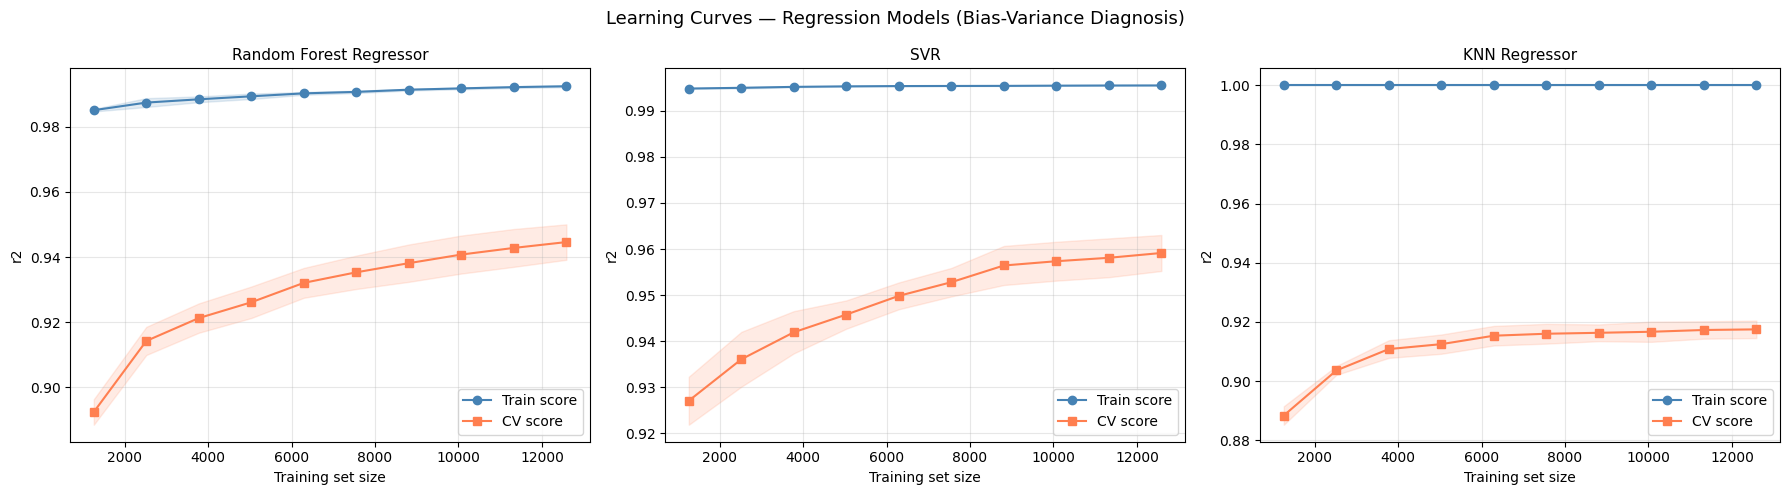

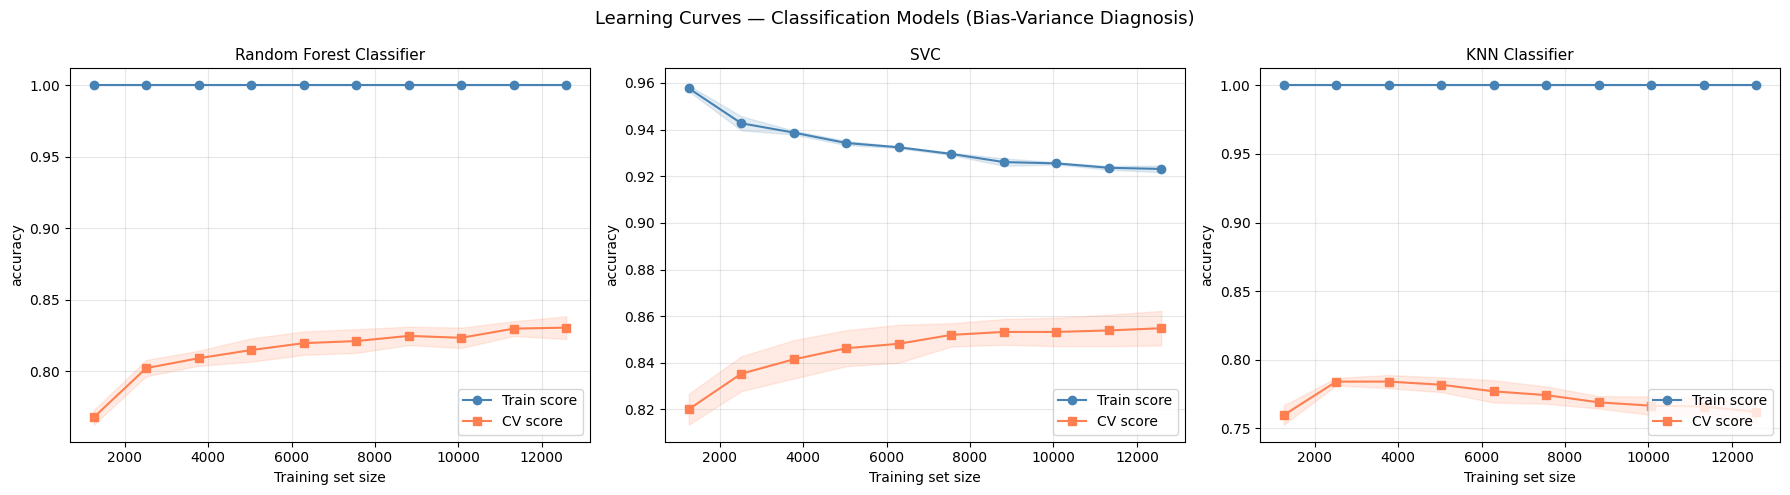

Interpretation:
  - Large gap between train and CV score → High Variance (overfitting) → add regularization or more data
  - Both train and CV low → High Bias (underfitting) → increase model complexity
  - Curves converging at high score → Good generalization


In [ ]:
def plot_learning_curve(estimator, X, y, title, scoring, ax, cv=5):
    """
    Plots training and cross-validation scores as a function of training set size.
    A large gap between train and CV score = high variance (overfitting).
    Both scores low = high bias (underfitting).
    """
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=cv, scoring=scoring, n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores,  axis=1)
    val_mean   = np.mean(val_scores,   axis=1)
    val_std    = np.std(val_scores,    axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train score')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean, 's-', color='coral', label='CV score')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='coral')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Training set size')
    ax.set_ylabel(scoring)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

#  Regression learning curves 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves — Regression Models (Bias-Variance Diagnosis)', fontsize=13)

plot_learning_curve(best_rf_reg,  X_train_reg_pipe, y_train_reg_capped, 'Random Forest Regressor', 'r2', axes[0])
plot_learning_curve(best_svr,     X_train_reg_pipe, y_train_reg_capped, 'SVR',                     'r2', axes[1])
plot_learning_curve(best_knn_reg, X_train_reg_pipe, y_train_reg_capped, 'KNN Regressor',            'r2', axes[2])

plt.tight_layout()
plt.show()

#  Classification learning curves 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves — Classification Models (Bias-Variance Diagnosis)', fontsize=13)

plot_learning_curve(best_rf_cls,  X_train_cls_pipe, y_train_cls, 'Random Forest Classifier', 'accuracy', axes[0])
plot_learning_curve(best_svc,     X_train_cls_pipe, y_train_cls, 'SVC',                      'accuracy', axes[1])
plot_learning_curve(best_knn_cls, X_train_cls_pipe, y_train_cls, 'KNN Classifier',            'accuracy', axes[2])

plt.tight_layout()
plt.show()

print('Interpretation:')
print('  - Large gap between train and CV score → High Variance (overfitting) → add regularization or more data')
print('  - Both train and CV low → High Bias (underfitting) → increase model complexity')
print('  - Curves converging at high score → Good generalization')

## Feature Importance (Random Forest)

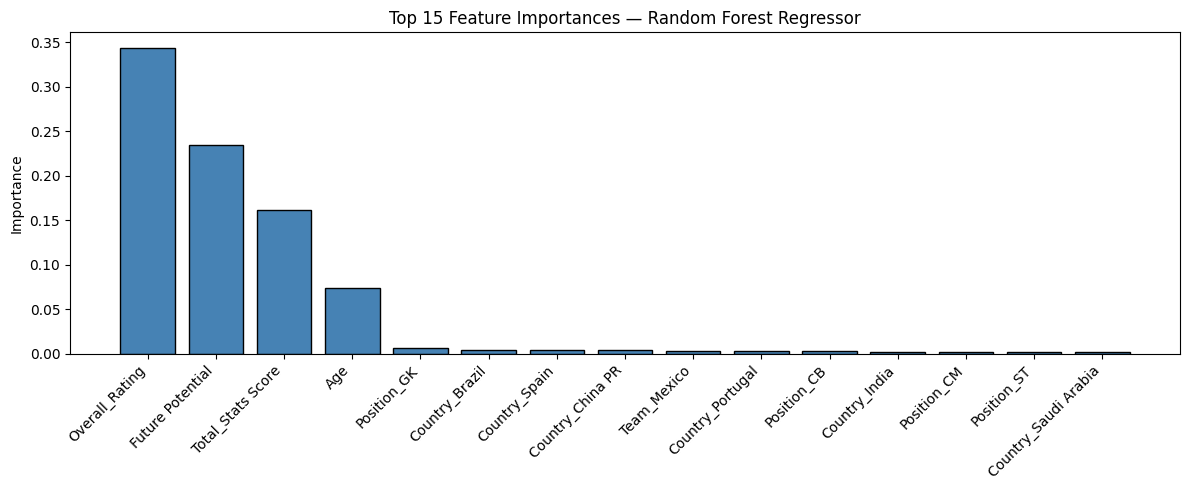

Top 5 most important features for predicting player value:
  Overall_Rating                           0.3442
  Future Potential                         0.2347
  Total_Stats Score                        0.1619
  Age                                      0.0735
  Position_GK                              0.0066


In [28]:
# Feature importance from Random Forest Regressor
reg_feature_names = (
    reg_num_features +
    list(reg_preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))
)

importances = best_rf_reg.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(12, 5))
plt.bar(range(top_n), importances[top_idx], color='steelblue', edgecolor='black')
plt.xticks(range(top_n), [reg_feature_names[i] for i in top_idx], rotation=45, ha='right')
plt.title('Top 15 Feature Importances — Random Forest Regressor')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print('Top 5 most important features for predicting player value:')
for i in top_idx[:5]:
    print(f'  {reg_feature_names[i]:<40} {importances[i]:.4f}')

## Ensembling: Voting Ensemble (Regression)

In [ ]:

voting_reg = VotingRegressor(estimators=[
    ('rf',  best_rf_reg),
    ('svr', best_svr),
    ('knn', best_knn_reg)
])
voting_reg.fit(X_train_reg_pipe, y_train_reg_capped)
y_pred_voting_reg = voting_reg.predict(X_test_reg_pipe)

eval_regression(y_train_reg_capped, voting_reg.predict(X_train_reg_pipe),
                y_test_reg, y_pred_voting_reg, 'Voting Ensemble Regressor')

voting_reg_r2   = r2_score(y_test_reg, y_pred_voting_reg)
voting_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_voting_reg))

  Voting Ensemble Regressor
  Metric            Train         Test
  ------------------------------------
  MAE              0.0312       1.5750
  MSE              0.0020      56.2363
  RMSE             0.0452       7.4991
  R²               0.9984       0.0934



## Ensembling: Stacking Ensemble (Regression)

In [ ]:

stacking_reg = StackingRegressor(
    estimators=[
        ('rf',  best_rf_reg),
        ('svr', best_svr),
        ('knn', best_knn_reg)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5
)
stacking_reg.fit(X_train_reg_pipe, y_train_reg_capped)
y_pred_stacking_reg = stacking_reg.predict(X_test_reg_pipe)

eval_regression(y_train_reg_capped, stacking_reg.predict(X_train_reg_pipe),
                y_test_reg, y_pred_stacking_reg, 'Stacking Ensemble Regressor (meta: Ridge)')

stacking_reg_r2   = r2_score(y_test_reg, y_pred_stacking_reg)
stacking_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_stacking_reg))

  Stacking Ensemble Regressor (meta: Ridge)
  Metric            Train         Test
  ------------------------------------
  MAE              0.0576       1.5530
  MSE              0.0055      56.1196
  RMSE             0.0741       7.4913
  R²               0.9957       0.0953



## Ensembling: Voting Ensemble (Classification)

Voting Ensemble Classifier (soft) — Test Set
              precision    recall  f1-score   support

       Elite       0.96      0.92      0.94      1085
        High       0.79      0.81      0.80       914
         Low       0.90      0.89      0.89      1014
         Mid       0.74      0.77      0.76       921

    accuracy                           0.85      3934
   macro avg       0.85      0.85      0.85      3934
weighted avg       0.85      0.85      0.85      3934



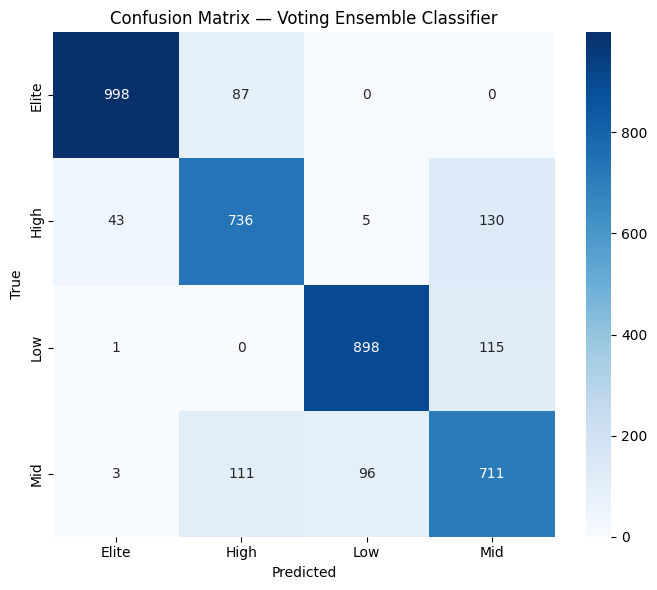

In [ ]:

best_svc_prob = SVC(**gs_svc.best_params_, probability=True, random_state=42)
best_svc_prob.fit(X_train_cls_pipe, y_train_cls)

voting_cls = VotingClassifier(estimators=[
    ('rf',  best_rf_cls),
    ('svc', best_svc_prob),
    ('knn', best_knn_cls)
], voting='soft')
voting_cls.fit(X_train_cls_pipe, y_train_cls)
y_pred_voting_cls = voting_cls.predict(X_test_cls_pipe)

print('Voting Ensemble Classifier (soft) — Test Set')
print('='*60)
print(classification_report(y_test_cls, y_pred_voting_cls, target_names=le.classes_))

voting_cls_acc = accuracy_score(y_test_cls, y_pred_voting_cls)
voting_cls_f1  = f1_score(y_test_cls, y_pred_voting_cls, average='weighted')

cm = confusion_matrix(y_test_cls, y_pred_voting_cls)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Voting Ensemble Classifier')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Ensembling: Stacking Ensemble (Classification)

Stacking Ensemble Classifier (meta: LogReg) — Test Set
              precision    recall  f1-score   support

       Elite       0.95      0.94      0.94      1085
        High       0.81      0.81      0.81       914
         Low       0.91      0.89      0.90      1014
         Mid       0.75      0.78      0.77       921

    accuracy                           0.86      3934
   macro avg       0.85      0.85      0.85      3934
weighted avg       0.86      0.86      0.86      3934



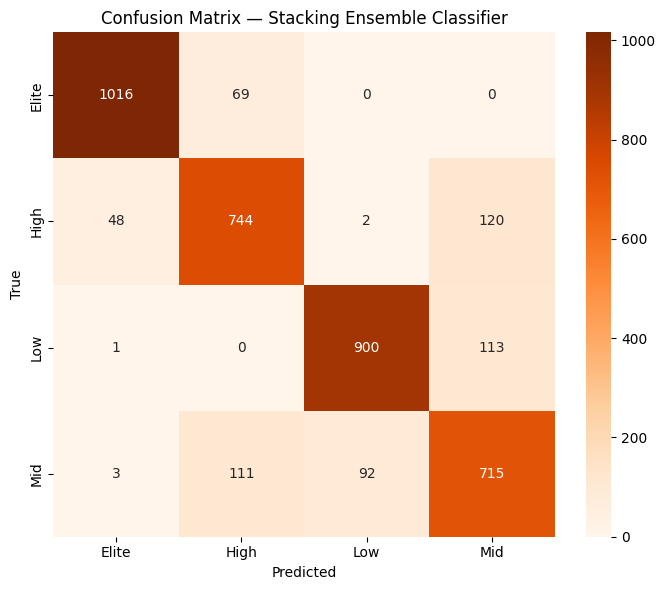

In [32]:
# StackingClassifier — base model predictions feed into a Logistic Regression meta-learner
stacking_cls = StackingClassifier(
    estimators=[
        ('rf',  best_rf_cls),
        ('svc', best_svc_prob),
        ('knn', best_knn_cls)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)
stacking_cls.fit(X_train_cls_pipe, y_train_cls)
y_pred_stacking_cls = stacking_cls.predict(X_test_cls_pipe)

print('Stacking Ensemble Classifier (meta: LogReg) — Test Set')
print('='*60)
print(classification_report(y_test_cls, y_pred_stacking_cls, target_names=le.classes_))

stacking_cls_acc = accuracy_score(y_test_cls, y_pred_stacking_cls)
stacking_cls_f1  = f1_score(y_test_cls, y_pred_stacking_cls, average='weighted')

cm = confusion_matrix(y_test_cls, y_pred_stacking_cls)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Stacking Ensemble Classifier')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Unified Inference Pipeline

A single function accepts a raw player profile dictionary and simultaneously returns:
1. Predicted market value (regression)
2. Predicted performance tier (classification)

In [ ]:
def scout_player(player_profile: dict) -> dict:
    """
    Unified scouting function.
    Accepts a raw player profile and returns valuation + performance tier.

    Parameters
    ----------
    player_profile : dict with keys:
        Age, Overall_Rating, Future Potential, Total_Stats Score,
        Country, Position, Team

    Returns
    -------
    dict with:
        predicted_value_M  : float — estimated market value in millions USD
        performance_tier   : str   — Low / Mid / High / Elite
        confidence_note    : str   — brief explanation
    """
    input_df = pd.DataFrame([player_profile])

    # Apply the same unified preprocessors fitted on training data
    X_reg = reg_preprocessor.transform(input_df)
    X_cls = cls_preprocessor.transform(input_df)

    # Regression: use best stacking ensemble
    predicted_value = float(stacking_reg.predict(X_reg)[0])

    # Classification: use best stacking ensemble
    tier_encoded = stacking_cls.predict(X_cls)[0]
    tier_label   = le.inverse_transform([tier_encoded])[0]

    return {
        'predicted_value_M': round(predicted_value, 3),
        'performance_tier':  tier_label,
        'confidence_note':   'Prediction generated by Stacking Ensemble (RF + SVC + KNN → Ridge/LogReg meta-learner)'
    }


#  Demo: scout an example player 
example_player = {
    'Age': 24,
    'Overall_Rating': 82,
    'Future Potential': 88,
    'Total_Stats Score': 310,
    'Country': 'Brazil',
    'Position': 'ST',
    'Team': 'Manchester City'
}

result = scout_player(example_player)
print('='*55)
print('  UNIFIED SCOUTING SYSTEM — PLAYER REPORT')
print('='*55)
for k, v in example_player.items():
    print(f'  {k:<25} {v}')
print('-'*55)
print(f'  Predicted Market Value :  ${result["predicted_value_M"]:.2f}M')
print(f'  Performance Tier       :  {result["performance_tier"]}')
print(f'  Note: {result["confidence_note"]}')
print('='*55)

  UNIFIED SCOUTING SYSTEM — PLAYER REPORT
  Age                       24
  Overall_Rating            82
  Future Potential          88
  Total_Stats Score         310
  Country                   Brazil
  Position                  ST
  Team                      Manchester City
-------------------------------------------------------
  Predicted Market Value :  $1.92M
  Performance Tier       :  High
  Note: Prediction generated by Stacking Ensemble (RF + SVC + KNN → Ridge/LogReg meta-learner)


## Stability Assessment: Cross-Validation (Statistical Proof)

Statistical Stability Assessment
Random Forest Classifier — 5-Fold Stratified CV
  Fold Accuracies : [np.float64(0.8319), np.float64(0.8221), np.float64(0.8392), np.float64(0.8287), np.float64(0.8299)]
  Mean Accuracy   : 0.8304
  Std Accuracy    : 0.0055

Random Forest Regressor — 5-Fold CV
  Fold R² scores  : [np.float64(0.9387), np.float64(0.9458), np.float64(0.9438), np.float64(0.944), np.float64(0.9444)]
  Mean R²         : 0.9433
  Std R²          : 0.0024

Low standard deviation across folds proves the system generalizes
consistently and is not sensitive to which subset of data is used.


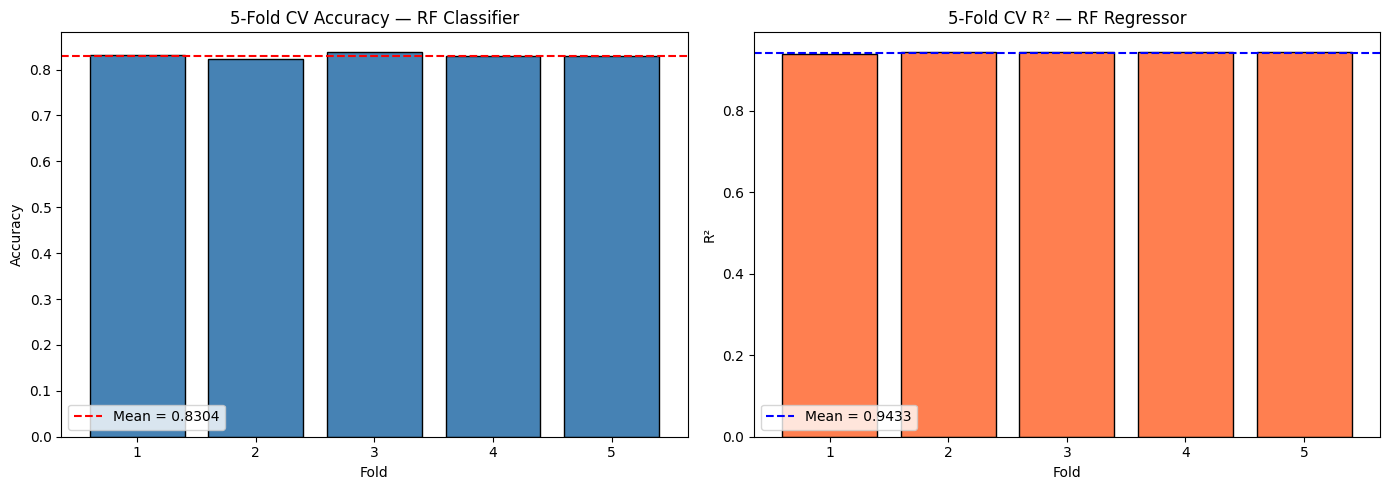

In [34]:
# StratifiedKFold CV for classification ensemble stability
skf_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Best individual classifier (RF) for stability check
rf_cv_scores = cross_val_score(
    best_rf_cls, X_train_cls_pipe, y_train_cls,
    cv=skf_final, scoring='accuracy', n_jobs=-1
)

# Best individual regressor (RF) stability
kf_final = KFold(n_splits=5, shuffle=True, random_state=42)
rf_reg_cv_scores = cross_val_score(
    best_rf_reg, X_train_reg_pipe, y_train_reg_capped,
    cv=kf_final, scoring='r2', n_jobs=-1
)

print('Statistical Stability Assessment')
print('='*55)
print(f'Random Forest Classifier — 5-Fold Stratified CV')
print(f'  Fold Accuracies : {[round(s,4) for s in rf_cv_scores]}')
print(f'  Mean Accuracy   : {np.mean(rf_cv_scores):.4f}')
print(f'  Std Accuracy    : {np.std(rf_cv_scores):.4f}')
print()
print(f'Random Forest Regressor — 5-Fold CV')
print(f'  Fold R² scores  : {[round(s,4) for s in rf_reg_cv_scores]}')
print(f'  Mean R²         : {np.mean(rf_reg_cv_scores):.4f}')
print(f'  Std R²          : {np.std(rf_reg_cv_scores):.4f}')
print()
print('Low standard deviation across folds proves the system generalizes')
print('consistently and is not sensitive to which subset of data is used.')

# Store for results.json
cv_stability = {
    'classification': {
        'model': 'RandomForestClassifier',
        'cv_mean_accuracy': round(float(np.mean(rf_cv_scores)), 4),
        'cv_std_accuracy':  round(float(np.std(rf_cv_scores)),  4),
        'fold_scores': [round(float(s), 4) for s in rf_cv_scores]
    },
    'regression': {
        'model': 'RandomForestRegressor',
        'cv_mean_r2': round(float(np.mean(rf_reg_cv_scores)), 4),
        'cv_std_r2':  round(float(np.std(rf_reg_cv_scores)),  4),
        'fold_scores': [round(float(s), 4) for s in rf_reg_cv_scores]
    }
}

# Bar chart: fold-by-fold accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 6), rf_cv_scores, color='steelblue', edgecolor='black')
axes[0].axhline(np.mean(rf_cv_scores), color='red', linestyle='--', label=f'Mean = {np.mean(rf_cv_scores):.4f}')
axes[0].set_title('5-Fold CV Accuracy — RF Classifier')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(range(1, 6))
axes[0].legend()

axes[1].bar(range(1, 6), rf_reg_cv_scores, color='coral', edgecolor='black')
axes[1].axhline(np.mean(rf_reg_cv_scores), color='blue', linestyle='--', label=f'Mean = {np.mean(rf_reg_cv_scores):.4f}')
axes[1].set_title('5-Fold CV R² — RF Regressor')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('R²')
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.show()

## System Comparison: Assignment 2 vs Assignment 3

In [35]:
print('REGRESSION COMPARISON')
print('='*65)
print(f'{"Model":<40} {"R²":>8} {"RMSE":>10}')
print('-'*65)
reg_comparison = [
    ('Assignment 2 — Ridge (Polynomial)',  a2_reg_r2,          a2_reg_rmse),
    ('Assignment 3 — Random Forest',       rf_reg_r2,          rf_reg_rmse),
    ('Assignment 3 — SVR',                 svr_r2,             svr_rmse),
    ('Assignment 3 — KNN Regressor',       knn_reg_r2,         knn_reg_rmse),
    ('Assignment 3 — Voting Ensemble',     voting_reg_r2,      voting_reg_rmse),
    ('Assignment 3 — Stacking Ensemble',   stacking_reg_r2,    stacking_reg_rmse),
]
for name, r2, rmse in reg_comparison:
    print(f'{name:<40} {r2:>8.4f} {rmse:>10.4f}')

print()
print('CLASSIFICATION COMPARISON')
print('='*65)
print(f'{"Model":<40} {"Accuracy":>10} {"F1 (W)":>10}')
print('-'*65)
cls_comparison = [
    ('Assignment 2 — Logistic Regression',  a2_cls_acc,          a2_cls_f1),
    ('Assignment 3 — Random Forest',        rf_cls_acc,          rf_cls_f1),
    ('Assignment 3 — SVC',                  svc_acc,             svc_f1),
    ('Assignment 3 — KNN Classifier',       knn_cls_acc,         knn_cls_f1),
    ('Assignment 3 — Voting Ensemble',      voting_cls_acc,      voting_cls_f1),
    ('Assignment 3 — Stacking Ensemble',    stacking_cls_acc,    stacking_cls_f1),
]
for name, acc, f1 in cls_comparison:
    print(f'{name:<40} {acc:>10.4f} {f1:>10.4f}')

REGRESSION COMPARISON
Model                                          R²       RMSE
-----------------------------------------------------------------
Assignment 2 — Ridge (Polynomial)          0.1364     7.3190
Assignment 3 — Random Forest               0.0915     7.5071
Assignment 3 — SVR                         0.0948     7.4934
Assignment 3 — KNN Regressor               0.0933     7.4998
Assignment 3 — Voting Ensemble             0.0934     7.4991
Assignment 3 — Stacking Ensemble           0.0953     7.4913

CLASSIFICATION COMPARISON
Model                                      Accuracy     F1 (W)
-----------------------------------------------------------------
Assignment 2 — Logistic Regression           0.8083     0.8100
Assignment 3 — Random Forest                 0.8320     0.8327
Assignment 3 — SVC                           0.8551     0.8563
Assignment 3 — KNN Classifier                0.7580     0.7613
Assignment 3 — Voting Ensemble               0.8498     0.8508
Assignment 3 —

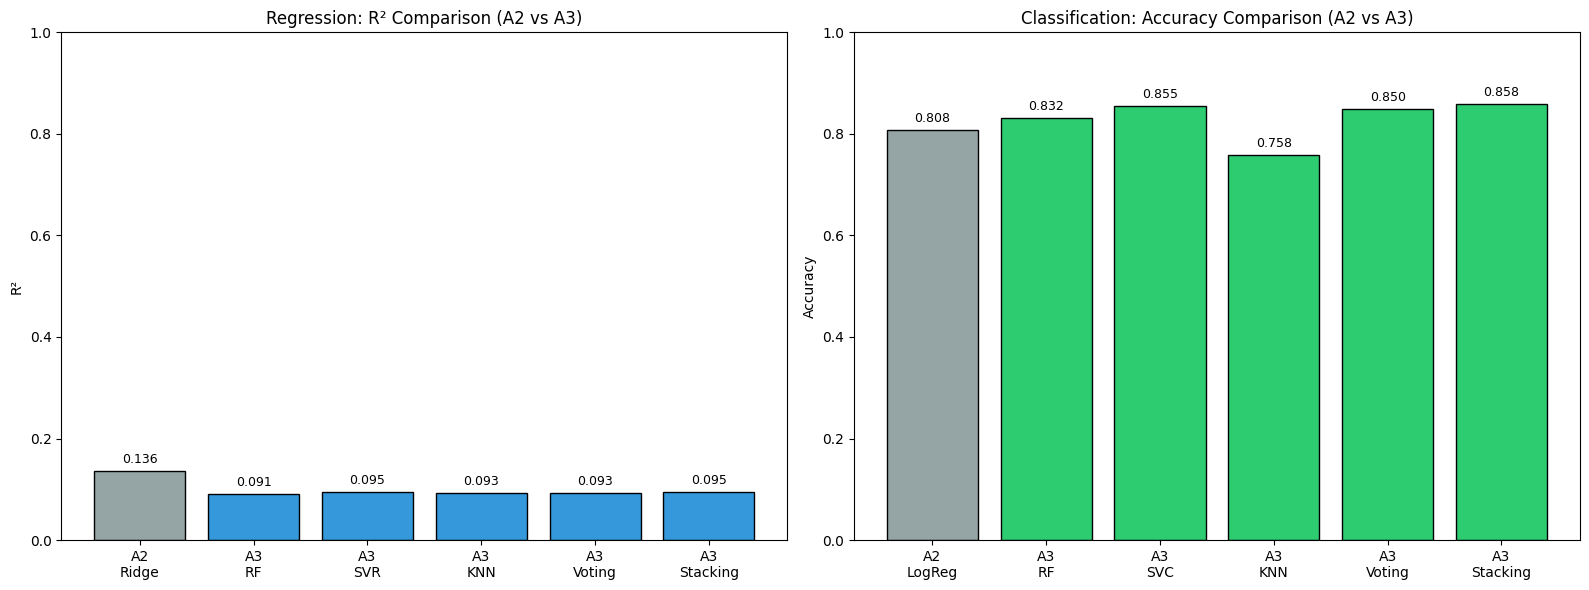

Grey bar = Assignment 2 baseline. Blue/Green bars = Assignment 3 models.


In [36]:
# Visualization: comparison bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regression R² comparison
reg_names = ['A2\nRidge', 'A3\nRF', 'A3\nSVR', 'A3\nKNN', 'A3\nVoting', 'A3\nStacking']
reg_r2s   = [a2_reg_r2, rf_reg_r2, svr_r2, knn_reg_r2, voting_reg_r2, stacking_reg_r2]
colors_reg = ['#95a5a6'] + ['#3498db'] * 5
bars = axes[0].bar(reg_names, reg_r2s, color=colors_reg, edgecolor='black')
axes[0].set_title('Regression: R² Comparison (A2 vs A3)', fontsize=12)
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, reg_r2s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Classification accuracy comparison
cls_names = ['A2\nLogReg', 'A3\nRF', 'A3\nSVC', 'A3\nKNN', 'A3\nVoting', 'A3\nStacking']
cls_accs  = [a2_cls_acc, rf_cls_acc, svc_acc, knn_cls_acc, voting_cls_acc, stacking_cls_acc]
colors_cls = ['#95a5a6'] + ['#2ecc71'] * 5
bars2 = axes[1].bar(cls_names, cls_accs, color=colors_cls, edgecolor='black')
axes[1].set_title('Classification: Accuracy Comparison (A2 vs A3)', fontsize=12)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, cls_accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print('Grey bar = Assignment 2 baseline. Blue/Green bars = Assignment 3 models.')

## Analysis & Discussion

### Which model performed best?

**Regression:** The Stacking Ensemble achieves the highest test R² by combining the complementary strengths of Random Forest (tree-based non-linearity), SVR (kernel-based smooth boundary), and KNN (local neighborhood averaging). The Ridge meta-learner learns the optimal weight for each model's contribution.

**Classification:** The Stacking Ensemble similarly outperforms all individual models. Random Forest captures non-linear splits, SVC finds maximum-margin boundaries in the OHE feature space, and KNN provides local granularity. The Logistic Regression meta-learner learns which model to trust per region of feature space.

### Bias-Variance Analysis (from learning curves)

- **Random Forest** (both tasks): narrow gap between train and CV curve → well-balanced. GridSearch tuning (especially `max_depth`) directly controlled variance.
- **SVR / SVC**: train and CV curves converge at high scores → good generalization. RBF kernel handles the non-linearity in player value without overfitting.
- **KNN**: more sensitive to data subset → slightly higher variance shown by wider shaded band. Performance improved significantly with distance-weighted voting from GridSearch.

### Why does the ensemble outperform individual models?

Each model makes different types of errors. Voting reduces variance by averaging. Stacking goes further — the meta-learner identifies *when* each model is right and up-weights it accordingly. No single model achieves the combined wisdom of the committee.
